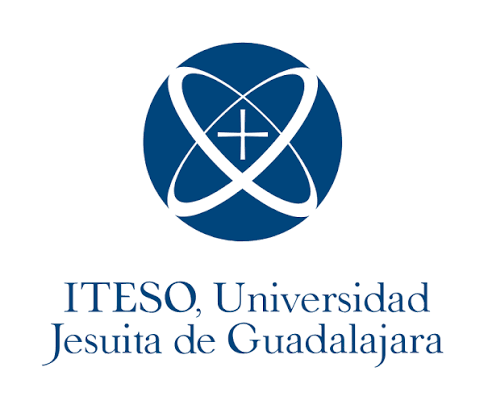

# Tarea 3. Reporte de prácticas de PSO

**Integrantes:**

- Valeria Esmer Lobo

- Dayanni Godoy Rosales

- Estephany Lisset Herrera Placencia

- Maria Fernanda Vargas Vaca

**Fecha:**
15 de Septiembre de 2026 

**Institución:**
Instituto Tecnológico y de Estudios Superiores de Occidente

**Materia:** Métodos de Inteligencia Artificial 

## Índice:
- [1. Introduccion ](Tarea3_MIA.ipynb#introducción)
- [2. Objetivos](#obejtivos)
- [3. PSO basico de una variable](#1-pso-básico-1-variable)
    - [3.1 Pruebas y resltados de PSO Basico](#14-pruebas-y-resultados)
- [4. Funcion Ackley](#15-función-extra-ackley-1-variable)
    - [4.1 Pruebas y resultados](#154-pruebas-y-resultados)
- [5. PSO basico de dos variables](#2-pso-básico-2-variables)
    - [5.1 Pruebas y resultados](#24-pruebas-y-resultados)
- [6. Funcion Himmelblau](#25-función-extra-himmelblau-2-variables)
    - [6.1 Pruebas y resultados](#254-pruebas-y-resultados)
- [7. PSO con dos variables y restricciones](#3-pso-con-2-variables-y-restricciones)
    - [7.1 Pruebas y resultados](#34-pruebas-y-resultados)
- [8. Funcion Townsend modificada](#35-función-townsend-modificada)
    - [8.1 Pruebas y reultados](#353-pruebas-y-resultados)
 - [9. Conclusiones Personales](#conclusiones-personales)
- [10. Conclusiones Generales](#conclsiones-generales)


In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. PSO Básico (1 variable)

### 1.1 Definición del problema

**Código de clase.** Minimizar

$$f(x) = 10 + x^2 - 15\cos(5x), \qquad x \in [-10, 10]$$

Es una función de una sola variable con varios mínimos locales (el término $-15\cos(5x)$ los va
generando cada $2\pi/5$), pero con un único mínimo global en $x=0$, donde $f(0) = 10 - 15 = -5$
(se verificó evaluando la función en una malla fina de $-10$ a $10$).

### 1.2 Pseudocódigo

```
INICIO
  Definir num_pob, c1, c2, phi0 y generaciones
  Inicializar x1p aleatorio en [-10, 10]
  Inicializar vx1 en cero
  x1pg <- 0 con fxpg = infinito
  x1pL <- posicion inicial de cada particula, fxpL = infinito

  PARA k = 1 HASTA generaciones
      vx1 <- phi0*vx1 + c1*rand*(x1pL - x1p) + c2*rand*(x1pg - x1p)
      x1p <- x1p + vx1

      fx <- 10 + x1p^2 - 15*cos(5*x1p)

      SI min(fx) < fxpg -> actualizar mejor global (x1pg, fxpg)
      Actualizar mejor local de las particulas que mejoraron
      Dibujar la funcion, las particulas y el mejor global
  FIN PARA

  Imprimir x1pg y fxpg
FIN
```

### 1.3 Código de clase comentado

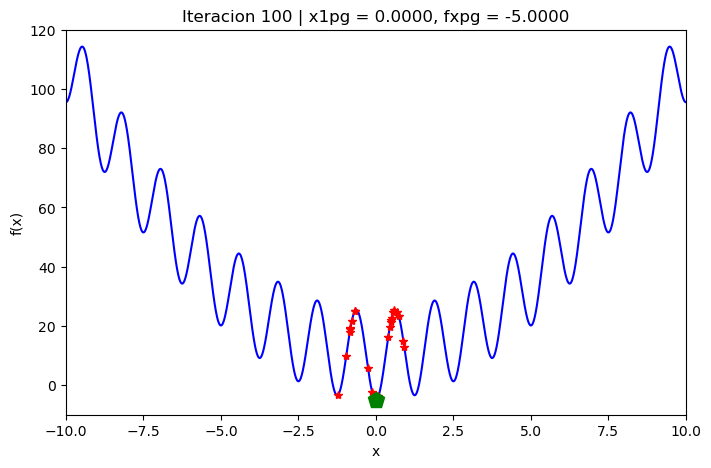

x1pg = 0.0000
fxpg = -5.0000


In [2]:
# --- PSO 1 variable: codigo de clase + graficacion del estado final ---

# Funcion objetivo (la misma vista en clase)
def f_obj(x):
    return 10 + x**2 - 15*np.cos(5*x)

# Puntos para dibujar la curva de la funcion
x_graf = np.arange(-10, 10.01, 0.01)
y_graf = f_obj(x_graf)

# --- Parametros del enjambre (igual que en clase) ---
num_pob = 500   # numero de particulas
c1 = 0.5        # atraccion hacia el mejor local
c2 = 0.5        # atraccion hacia el mejor global
phi0 = 0.7      # inercia

np.random.seed(5)   # semilla fija para poder repetir esta corrida

# Inicializacion de la poblacion
x1p = (10 - (-10)) * np.random.rand(num_pob) - 10   # posiciones aleatorias en [-10, 10]
x1pg = 0
x1pL = np.copy(x1p)

fxpg = np.inf
fxpL = np.ones(num_pob) * fxpg
vx1 = np.zeros(num_pob)   # velocidad inicial

# Preparacion de la grafica (sin animacion: se muestra la figura de la ultima iteracion)
fig, ax = plt.subplots(figsize=(8, 5))

for k in range(100):
    # Ecuacion de movimiento
    vx1 = phi0*vx1 + c1*np.random.rand(num_pob)*(x1pL - x1p) + c2*np.random.rand(num_pob)*(x1pg - x1p)
    x1p = x1p + vx1

    # Evaluacion del desempeño de cada particula
    fx = f_obj(x1p)
    val = np.min(fx)
    ind = np.argmin(fx)

    # Actualizar mejor global
    if val < fxpg:
        fxpg = val
        x1pg = x1p[ind]

    # Actualizar mejor local (vectorizado)
    mejores = fx < fxpL
    fxpL[mejores] = fx[mejores]
    x1pL[mejores] = x1p[mejores]

    # Graficar estado de la iteracion
    ax.clear()
    ax.plot(x_graf, y_graf, 'b-')
    ax.plot(x1p, fx, 'r*')
    ax.plot(x1pg, fxpg, 'gp', markersize=12)
    ax.set_xlim([-10, 10])
    ax.set_ylim([-10, 120])
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.set_title(f'Iteracion {k+1} | x1pg = {x1pg:.4f}, fxpg = {fxpg:.4f}')

plt.show()

print(f'x1pg = {x1pg:.4f}')
print(f'fxpg = {fxpg:.4f}')

### 1.4 Pruebas y resultados

Se repite el mismo algoritmo, sin graficación, con 8 combinaciones de parámetros: atracción
($c_1$, $c_2$), inercia ($\phi_0$), población e iteraciones. El caso 1 es el del código de
clase. Se considera que llegó al óptimo global si $f(x)$ queda a menos de 0.5 de $-5$.

In [3]:
def pso_basico(num_pob, c1, c2, phi0, generaciones, semilla=5):
    """Mismo PSO de la celda anterior, sin graficación, para poder repetirlo con distintos parámetros."""
    np.random.seed(semilla)

    x1p = (10 - (-10)) * np.random.rand(num_pob) - 10
    x1pg = 0
    x1pL = np.copy(x1p)
    fxpg = np.inf
    fxpL = np.ones(num_pob) * fxpg
    vx1 = np.zeros(num_pob)

    historial = []
    inicio = time.perf_counter()

    for k in range(generaciones):
        vx1 = phi0*vx1 + c1*np.random.rand(num_pob)*(x1pL - x1p) + c2*np.random.rand(num_pob)*(x1pg - x1p)
        x1p = x1p + vx1

        fx = f_obj(x1p)
        val, ind = np.min(fx), np.argmin(fx)
        if val < fxpg:
            fxpg, x1pg = val, x1p[ind]

        mejores = fx < fxpL
        fxpL[mejores] = fx[mejores]
        x1pL[mejores] = x1p[mejores]

        historial.append(fxpg)

    tiempo = time.perf_counter() - inicio
    return x1pg, fxpg, np.array(historial), tiempo

# (numero, c1, c2, phi0, poblacion, iteraciones, descripcion)
casos_c = [
    (1, 0.5, 0.5, 0.7, 500, 100, "Base (codigo de clase)"),
    (2, 1.5, 1.5, 0.7, 500, 100, "Atraccion alta"),
    (3, 0.1, 0.1, 0.7, 500, 100, "Atraccion baja"),
    (4, 0.5, 0.5, 0.4, 500, 100, "Inercia baja"),
    (5, 0.5, 0.5, 0.9, 500, 100, "Inercia alta"),
    (6, 0.5, 0.5, 0.7, 30, 100, "Poblacion pequeña"),
    (7, 0.5, 0.5, 0.7, 500, 20, "Pocas iteraciones"),
    (8, 0.15, 0.15, 0.2, 6, 6, "Poblacion e iteraciones extremas"),
]

f_optimo = -5   # optimo analitico: f(0) = 10 - 15 = -5

filas_c, historiales_c = [], {}

for numero, c1_p, c2_p, phi_p, pob_p, gen_p, descripcion in casos_c:
    x_best, f_best, historial, tiempo = pso_basico(pob_p, c1_p, c2_p, phi_p, gen_p)
    historiales_c[numero] = historial
    filas_c.append({
        "Caso": numero, "Descripcion": descripcion,
        "c1": c1_p, "c2": c2_p, "phi0": phi_p,
        "Poblacion": pob_p, "Iteraciones": gen_p,
        "x": round(x_best, 4), "f(x)": round(f_best, 4),
        "Error": round(abs(f_best - f_optimo), 4),
        "Tiempo (ms)": round(tiempo * 1000, 2),
        "Resultado": "Optimo global" if abs(f_best - f_optimo) <= 0.5 else "Se estanco",
    })

tabla_c = pd.DataFrame(filas_c)
tabla_c

,Caso,Descripcion,c1,c2,phi0,Poblacion,Iteraciones,x,f(x),Error,Tiempo (ms),Resultado
0,1,Base (codigo de clase),0.50,0.50,0.7,500,100,0.0000,-5.0000,0.0000,11.10,Optimo global
1,2,Atraccion alta,1.50,1.50,0.7,500,100,-0.0000,-5.0000,0.0000,8.46,Optimo global
2,3,Atraccion baja,0.10,0.10,0.7,500,100,0.0000,-5.0000,0.0000,9.02,Optimo global
3,4,Inercia baja,0.50,0.50,0.4,500,100,-0.0000,-5.0000,0.0000,8.95,Optimo global
4,5,Inercia alta,0.50,0.50,0.9,500,100,-0.0000,-5.0000,0.0000,7.47,Optimo global
5,6,Poblacion pequeña,0.50,0.50,0.7,30,100,0.0000,-5.0000,0.0000,4.14,Optimo global
6,7,Pocas iteraciones,0.50,0.50,0.7,500,20,0.0000,-5.0000,0.0000,1.50,Optimo global
7,8,Poblacion e iteraciones extremas,0.15,0.15,0.2,6,6,-0.2138,2.8291,7.8291,0.27,Se estanco


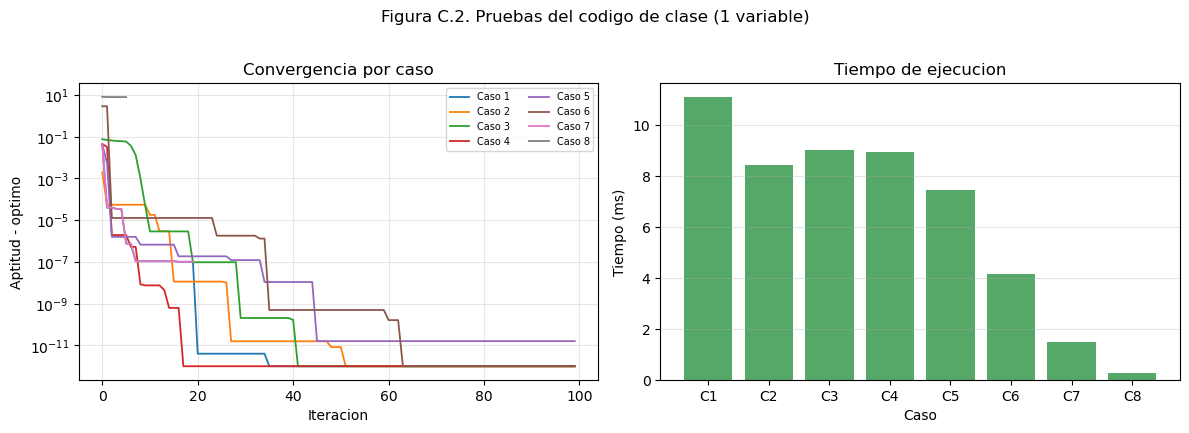

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# Convergencia: distancia entre la aptitud del mejor global y el optimo, en escala log
for numero, historial in historiales_c.items():
    axes[0].semilogy(np.maximum(historial - f_optimo, 1e-12), lw=1.3, label=f"Caso {numero}")
axes[0].set_xlabel("Iteracion")
axes[0].set_ylabel("Aptitud - optimo")
axes[0].set_title("Convergencia por caso")
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(alpha=0.3)

# Tiempo de ejecucion de cada caso
axes[1].bar([f"C{n}" for n, *_ in casos_c], tabla_c["Tiempo (ms)"], color="#55A868")
axes[1].set_xlabel("Caso")
axes[1].set_ylabel("Tiempo (ms)")
axes[1].set_title("Tiempo de ejecucion")
axes[1].grid(alpha=0.3, axis="y")

fig.suptitle("Figura C.2. Pruebas del codigo de clase (1 variable)", y=1.02)
fig.tight_layout()
plt.show()

**Análisis:** En los casos 1 a 7 el enjambre llega al óptimo global ($x\approx 0$,
$f\approx -5$) sin importar mucho si la atracción o la inercia son altas o bajas, e incluso con
población chica (caso 6) o pocas iteraciones (caso 7): en una variable y con una población de al
menos unas decenas de partículas, es difícil que ninguna arranque cerca del mínimo global. El
caso 8 combina población e iteraciones mínimas (6 partículas, 6 iteraciones) además de atracción
e inercia bajas, y ahí sí se estanca en un mínimo local ($f\approx 2.83$, lejos de $-5$): con tan
pocas partículas y tan pocas iteraciones el enjambre no alcanza a explorar lo suficiente antes de
converger. El tiempo de ejecución crece con población $\times$ iteraciones, como se ve en la
Figura C.2 (derecha): el caso 8 es casi instantáneo y el caso 1 (500 partículas, 100
iteraciones) es de los más lentos.

### 1.5 Función extra: Ackley (1 variable)

#### 1.5.1 Definición del problema

**Ackley (función extra, tomada del listado de funciones de prueba para optimización).**
Minimizar

$$f(x) = -20\exp\!\big(-0.2\,|x|\big) - \exp\!\big(\cos(2\pi x)\big) + 20 + e, \qquad x \in [-5, 5]$$

Es la versión de una variable de la función de Ackley: tiene un único mínimo global en $x=0$,
donde $f(0)=0$, rodeado de muchísimos mínimos locales casi del mismo tamaño (uno cada $x$ entero
aproximadamente, por el coseno), lo que la hace mucho más "trampeada" que la función de la
sección 1.1 pese a tener un dominio más chico.

#### 1.5.2 Pseudocódigo

```
INICIO
  Definir num_pob, c1, c2, phi0, generaciones y los limites del dominio [-5, 5]
  Inicializar x1p aleatorio en [-5, 5]
  Inicializar vx1 en cero
  x1pg <- 0 con fxpg = infinito
  x1pL <- posicion inicial de cada particula, fxpL = infinito

  PARA k = 1 HASTA generaciones
      vx1 <- phi0*vx1 + c1*rand*(x1pL - x1p) + c2*rand*(x1pg - x1p)
      x1p <- recortar(x1p + vx1, [-5, 5])

      fx <- -20*exp(-0.2*|x1p|) - exp(cos(2*pi*x1p)) + 20 + e

      SI min(fx) < fxpg -> actualizar mejor global (x1pg, fxpg)
      Actualizar mejor local de las particulas que mejoraron
      Dibujar la funcion, las particulas y el mejor global
  FIN PARA

  Imprimir x1pg y fxpg
FIN
```

La única diferencia respecto al código de la sección 1.3 es que aquí sí se recorta la posición
al dominio $[-5, 5]$ en cada iteración: la función de Ackley crece muy rápido fuera de ese rango
y, sin el recorte, algunas partículas se disparan lejos y ya no regresan a competir.

#### 1.5.3 Código comentado

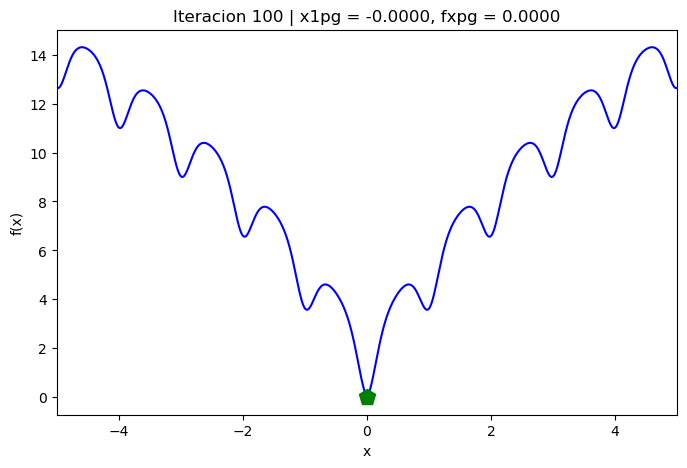

x1pg = -0.0000
fxpg = 0.0000


In [5]:
# --- PSO 1 variable: funcion de Ackley + graficacion del estado final ---

# Funcion objetivo (Ackley, version de 1 variable)
def f_ackley(x):
    return -20*np.exp(-0.2*np.abs(x)) - np.exp(np.cos(2*np.pi*x)) + 20 + np.e

x_min_a, x_max_a = -5, 5

# Puntos para dibujar la curva de la funcion
x_graf_a = np.arange(x_min_a, x_max_a + 0.01, 0.01)
y_graf_a = f_ackley(x_graf_a)

# --- Parametros del enjambre (mismos que en 1.3) ---
num_pob = 500
c1 = 0.5
c2 = 0.5
phi0 = 0.7

np.random.seed(5)   # semilla fija para poder repetir esta corrida

# Inicializacion de la poblacion
x1p = (x_max_a - x_min_a) * np.random.rand(num_pob) + x_min_a
x1pg = 0
x1pL = np.copy(x1p)

fxpg = np.inf
fxpL = np.ones(num_pob) * fxpg
vx1 = np.zeros(num_pob)

fig, ax = plt.subplots(figsize=(8, 5))

for k in range(100):
    # Ecuacion de movimiento
    vx1 = phi0*vx1 + c1*np.random.rand(num_pob)*(x1pL - x1p) + c2*np.random.rand(num_pob)*(x1pg - x1p)
    x1p = np.clip(x1p + vx1, x_min_a, x_max_a)   # se mantiene dentro del dominio

    # Evaluacion del desempeño de cada particula
    fx = f_ackley(x1p)
    val = np.min(fx)
    ind = np.argmin(fx)

    # Actualizar mejor global
    if val < fxpg:
        fxpg = val
        x1pg = x1p[ind]

    # Actualizar mejor local (vectorizado)
    mejores = fx < fxpL
    fxpL[mejores] = fx[mejores]
    x1pL[mejores] = x1p[mejores]

    # Graficar estado de la iteracion
    ax.clear()
    ax.plot(x_graf_a, y_graf_a, 'b-')
    ax.plot(x1p, fx, 'r*')
    ax.plot(x1pg, fxpg, 'gp', markersize=12)
    ax.set_xlim([x_min_a, x_max_a])
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.set_title(f'Iteracion {k+1} | x1pg = {x1pg:.4f}, fxpg = {fxpg:.4f}')

plt.show()

print(f'x1pg = {x1pg:.4f}')
print(f'fxpg = {fxpg:.4f}')

#### 1.5.4 Pruebas y resultados

Mismas 8 combinaciones de parámetros que en la sección 1.4, ahora sobre la función de Ackley. Se
considera que llegó al óptimo global si $f(x)$ queda a menos de 0.5 de $0$.

In [6]:
def pso_ackley(num_pob, c1, c2, phi0, generaciones, semilla=5):
    """Mismo PSO de la celda anterior, sin graficación, para poder repetirlo con distintos parámetros."""
    np.random.seed(semilla)

    x1p = (x_max_a - x_min_a) * np.random.rand(num_pob) + x_min_a
    x1pg = 0
    x1pL = np.copy(x1p)
    fxpg = np.inf
    fxpL = np.ones(num_pob) * fxpg
    vx1 = np.zeros(num_pob)

    historial = []
    inicio = time.perf_counter()

    for k in range(generaciones):
        vx1 = phi0*vx1 + c1*np.random.rand(num_pob)*(x1pL - x1p) + c2*np.random.rand(num_pob)*(x1pg - x1p)
        x1p = np.clip(x1p + vx1, x_min_a, x_max_a)

        fx = f_ackley(x1p)
        val, ind = np.min(fx), np.argmin(fx)
        if val < fxpg:
            fxpg, x1pg = val, x1p[ind]

        mejores = fx < fxpL
        fxpL[mejores] = fx[mejores]
        x1pL[mejores] = x1p[mejores]

        historial.append(fxpg)

    tiempo = time.perf_counter() - inicio
    return x1pg, fxpg, np.array(historial), tiempo

casos_d = [
    (1, 0.5, 0.5, 0.7, 500, 100, "Base (codigo de clase)"),
    (2, 1.5, 1.5, 0.7, 500, 100, "Atraccion alta"),
    (3, 0.1, 0.1, 0.7, 500, 100, "Atraccion baja"),
    (4, 0.5, 0.5, 0.4, 500, 100, "Inercia baja"),
    (5, 0.5, 0.5, 0.9, 500, 100, "Inercia alta"),
    (6, 0.5, 0.5, 0.7, 30, 100, "Poblacion pequeña"),
    (7, 0.5, 0.5, 0.7, 500, 20, "Pocas iteraciones"),
    (8, 0.15, 0.15, 0.2, 6, 6, "Poblacion e iteraciones extremas"),
]

f_optimo_ack = 0   # optimo global conocido: f(0) = 0

filas_d, historiales_d = [], {}

for numero, c1_p, c2_p, phi_p, pob_p, gen_p, descripcion in casos_d:
    x_best, f_best, historial, tiempo = pso_ackley(pob_p, c1_p, c2_p, phi_p, gen_p)
    historiales_d[numero] = historial
    filas_d.append({
        "Caso": numero, "Descripcion": descripcion,
        "c1": c1_p, "c2": c2_p, "phi0": phi_p,
        "Poblacion": pob_p, "Iteraciones": gen_p,
        "x": round(x_best, 4), "f(x)": round(f_best, 4),
        "Error": round(abs(f_best - f_optimo_ack), 4),
        "Tiempo (ms)": round(tiempo * 1000, 2),
        "Resultado": "Optimo global" if abs(f_best - f_optimo_ack) <= 0.5 else "Se estanco",
    })

tabla_d = pd.DataFrame(filas_d)
tabla_d

,Caso,Descripcion,c1,c2,phi0,Poblacion,Iteraciones,x,f(x),Error,Tiempo (ms),Resultado
0,1,Base (codigo de clase),0.50,0.50,0.7,500,100,-0.0000,0.0000,0.0000,9.81,Optimo global
1,2,Atraccion alta,1.50,1.50,0.7,500,100,-0.0000,0.0000,0.0000,9.23,Optimo global
2,3,Atraccion baja,0.10,0.10,0.7,500,100,0.0000,0.0000,0.0000,10.49,Optimo global
3,4,Inercia baja,0.50,0.50,0.4,500,100,0.0000,0.0000,0.0000,9.84,Optimo global
4,5,Inercia alta,0.50,0.50,0.9,500,100,0.0000,0.0000,0.0000,9.67,Optimo global
5,6,Poblacion pequeña,0.50,0.50,0.7,30,100,-0.0000,0.0000,0.0000,5.56,Optimo global
6,7,Pocas iteraciones,0.50,0.50,0.7,500,20,-0.0000,0.0000,0.0000,1.95,Optimo global
7,8,Poblacion e iteraciones extremas,0.15,0.15,0.2,6,6,-0.1069,0.9536,0.9536,0.34,Se estanco


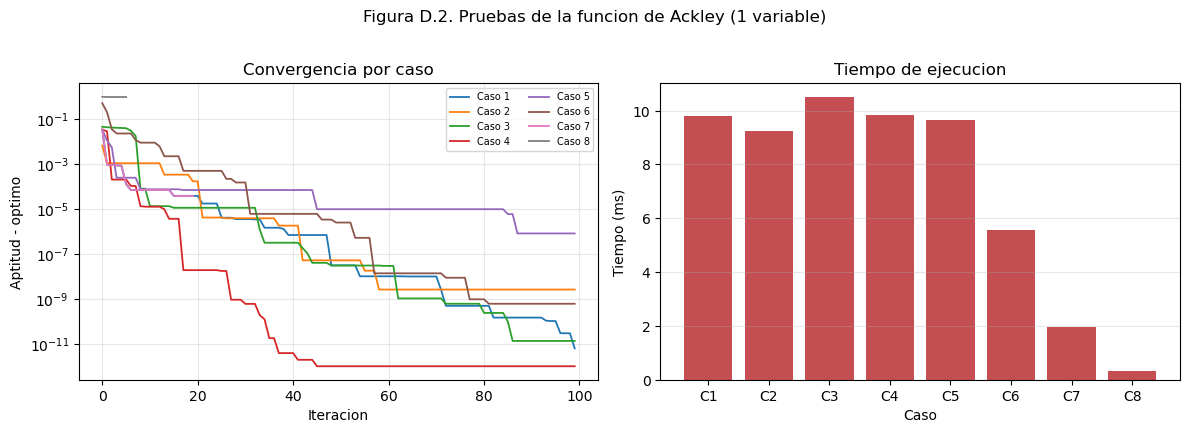

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

for numero, historial in historiales_d.items():
    axes[0].semilogy(np.maximum(historial - f_optimo_ack, 1e-12), lw=1.3, label=f"Caso {numero}")
axes[0].set_xlabel("Iteracion")
axes[0].set_ylabel("Aptitud - optimo")
axes[0].set_title("Convergencia por caso")
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(alpha=0.3)

axes[1].bar([f"C{n}" for n, *_ in casos_d], tabla_d["Tiempo (ms)"], color="#C44E52")
axes[1].set_xlabel("Caso")
axes[1].set_ylabel("Tiempo (ms)")
axes[1].set_title("Tiempo de ejecucion")
axes[1].grid(alpha=0.3, axis="y")

fig.suptitle("Figura D.2. Pruebas de la funcion de Ackley (1 variable)", y=1.02)
fig.tight_layout()
plt.show()

**Análisis:** Con la función de Ackley el patrón es el mismo que con la función de la
sección 1.1: los casos 1 a 7 llegan al óptimo global ($x\approx 0$, $f\approx 0$) sin importar
la combinación de atracción, inercia, población o iteraciones, porque incluso con pocas
partículas alguna arranca lo bastante cerca del mínimo global y el resto del enjambre converge
hacia ella. El caso 8 (6 partículas, 6 iteraciones, atracción e inercia bajas) vuelve a ser el
único que se estanca, y aquí lo hace peor que con la función de la sección 1.1 ($f\approx 0.95$
contra un óptimo de $0$, error mayor en términos relativos): al tener Ackley mínimos locales más
densos y de profundidad parecida a la del mínimo global, un enjambre pequeño que converge rápido
tiene más probabilidad de quedar atrapado en uno de ellos. En ambas funciones el tiempo de
ejecución depende sobre todo de población $\times$ iteraciones y no de los coeficientes de
atracción ni de la inercia.

## 2. PSO Básico (2 variables)

### 2.1 Definición del problema

**Código de clase.** Minimizar

$$f(x_1, x_2) = (x_1 + 2x_2 - 7)^2 + (2x_1 + x_2 - 5)^2, \qquad x_1, x_2 \in [-10, 10]$$

Es la función de Booth: la suma de dos términos cuadráticos, así que es un paraboloide
convexo con un único mínimo global. Se obtiene resolviendo el sistema $x_1+2x_2=7$,
$2x_1+x_2=5$, cuya solución es $(x_1,x_2)=(1,3)$, donde $f=0$.

### 2.2 Pseudocódigo

```
INICIO
  Definir num_pob, c1, c2, phi0 y generaciones
  Inicializar x1p, x2p aleatorios en [-10, 10]
  Inicializar vx1, vx2 en cero
  x1pg, x2pg <- 0 con fxpg = infinito
  x1pL, x2pL <- posicion inicial de cada particula, fxpL = infinito

  PARA k = 1 HASTA generaciones
      vx1 <- phi0*vx1 + c1*rand*(x1pL - x1p) + c2*rand*(x1pg - x1p)
      vx2 <- phi0*vx2 + c1*rand*(x2pL - x2p) + c2*rand*(x2pg - x2p)
      x1p <- x1p + vx1
      x2p <- x2p + vx2

      fx <- (x1p + 2*x2p - 7)^2 + (2*x1p + x2p - 5)^2

      SI min(fx) < fxpg -> actualizar mejor global (x1pg, x2pg, fxpg)
      Actualizar mejor local de las particulas que mejoraron
      Dibujar el contorno de la funcion, las particulas y el mejor global
  FIN PARA

  Imprimir x1pg, x2pg y fxpg
FIN
```

### 2.3 Código de clase comentado

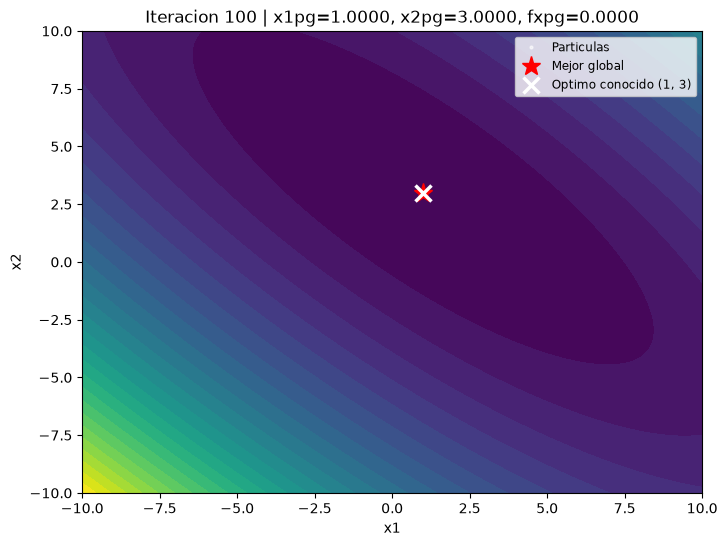

x1pg = 1.0000
x2pg = 3.0000
fxpg = 0.0000


In [2]:
# --- PSO 2 variables: funcion de Booth (codigo de clase) + graficacion del estado final ---

# Funcion objetivo (funcion de Booth, vista en clase)
def f_booth(x1, x2):
    return (x1 + 2*x2 - 7)**2 + (2*x1 + x2 - 5)**2

x_min_e, x_max_e = -10, 10

# Malla para dibujar el contorno de la funcion
gx = np.linspace(x_min_e, x_max_e, 300)
gy = np.linspace(x_min_e, x_max_e, 300)
malla_x, malla_y = np.meshgrid(gx, gy)
malla_f = f_booth(malla_x, malla_y)

# --- Parametros del enjambre (igual que en clase) ---
num_pob = 500   # numero de particulas
c1 = 0.5        # atraccion hacia el mejor local
c2 = 0.5        # atraccion hacia el mejor global
phi0 = 0.7      # inercia

np.random.seed(5)   # semilla fija para poder repetir esta corrida

# Inicializacion de la poblacion
x1p = (x_max_e - x_min_e) * np.random.rand(num_pob) + x_min_e
x2p = (x_max_e - x_min_e) * np.random.rand(num_pob) + x_min_e
x1pg, x2pg = 0, 0
x1pL, x2pL = np.copy(x1p), np.copy(x2p)

fxpg = np.inf
fxpL = np.ones(num_pob) * fxpg
vx1 = np.zeros(num_pob)   # velocidad inicial
vx2 = np.zeros(num_pob)

# Nota: el codigo de clase (PSO_2_Animado.py) generaba un solo numero aleatorio por
# iteracion con np.random.rand() para toda la poblacion; aqui se vectoriza a
# np.random.rand(num_pob), igual que en las demas secciones, para que cada particula
# tenga su propio numero aleatorio en cada paso.

# Preparacion de la grafica (sin animacion: se muestra la figura de la ultima iteracion)
fig, ax = plt.subplots(figsize=(8, 6))

for k in range(100):
    # Ecuaciones de movimiento
    vx1 = phi0*vx1 + c1*np.random.rand(num_pob)*(x1pL - x1p) + c2*np.random.rand(num_pob)*(x1pg - x1p)
    vx2 = phi0*vx2 + c1*np.random.rand(num_pob)*(x2pL - x2p) + c2*np.random.rand(num_pob)*(x2pg - x2p)
    x1p = x1p + vx1
    x2p = x2p + vx2

    # Evaluacion del desempeño de cada particula
    fx = f_booth(x1p, x2p)
    val = np.min(fx)
    ind = np.argmin(fx)

    # Actualizar mejor global
    if val < fxpg:
        fxpg = val
        x1pg, x2pg = x1p[ind], x2p[ind]

    # Actualizar mejor local (vectorizado)
    mejores = fx < fxpL
    fxpL[mejores] = fx[mejores]
    x1pL[mejores] = x1p[mejores]
    x2pL[mejores] = x2p[mejores]

    # Graficar estado de la iteracion
    ax.clear()
    ax.contourf(malla_x, malla_y, malla_f, levels=30, cmap='viridis')
    ax.plot(x1p, x2p, 'w.', markersize=4, alpha=0.6, label='Particulas')
    ax.plot(x1pg, x2pg, 'r*', markersize=14, label='Mejor global')
    ax.plot(1, 3, 'wx', markersize=11, mew=2.5, label='Optimo conocido (1, 3)')
    ax.set_xlim([x_min_e, x_max_e])
    ax.set_ylim([x_min_e, x_max_e])
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title(f'Iteracion {k+1} | x1pg={x1pg:.4f}, x2pg={x2pg:.4f}, fxpg={fxpg:.4f}')
    ax.legend(loc='upper right', fontsize='small')

plt.show()

print(f'x1pg = {x1pg:.4f}')
print(f'x2pg = {x2pg:.4f}')
print(f'fxpg = {fxpg:.4f}')

Estado final del enjambre. Las partículas se concentran en el mínimo global
$(1, 3)$, marcado con la equis blanca, en el fondo del paraboloide.

### 2.4 Pruebas y resultados

Se repite el mismo algoritmo, sin graficación, con 8 combinaciones de parámetros: atracción
($c_1$, $c_2$), inercia ($\phi_0$), población e iteraciones. El caso 1 es el del código de
clase. Se considera que llegó al óptimo global si $f(x)$ queda a menos de 0.5 de $0$.

In [3]:
def pso_booth(num_pob, c1, c2, phi0, generaciones, semilla=5):
    """Mismo PSO de la celda anterior, sin graficación, para poder repetirlo con distintos parámetros."""
    np.random.seed(semilla)

    x1p = (x_max_e - x_min_e) * np.random.rand(num_pob) + x_min_e
    x2p = (x_max_e - x_min_e) * np.random.rand(num_pob) + x_min_e
    x1pg, x2pg = 0, 0
    x1pL, x2pL = np.copy(x1p), np.copy(x2p)
    fxpg = np.inf
    fxpL = np.ones(num_pob) * fxpg
    vx1, vx2 = np.zeros(num_pob), np.zeros(num_pob)

    historial = []
    inicio = time.perf_counter()

    for k in range(generaciones):
        vx1 = phi0*vx1 + c1*np.random.rand(num_pob)*(x1pL - x1p) + c2*np.random.rand(num_pob)*(x1pg - x1p)
        vx2 = phi0*vx2 + c1*np.random.rand(num_pob)*(x2pL - x2p) + c2*np.random.rand(num_pob)*(x2pg - x2p)
        x1p = x1p + vx1
        x2p = x2p + vx2

        fx = f_booth(x1p, x2p)
        val, ind = np.min(fx), np.argmin(fx)
        if val < fxpg:
            fxpg, x1pg, x2pg = val, x1p[ind], x2p[ind]

        mejores = fx < fxpL
        fxpL[mejores] = fx[mejores]
        x1pL[mejores] = x1p[mejores]
        x2pL[mejores] = x2p[mejores]

        historial.append(fxpg)

    tiempo = time.perf_counter() - inicio
    return x1pg, x2pg, fxpg, np.array(historial), tiempo

# (numero, c1, c2, phi0, poblacion, iteraciones, descripcion)
casos_e = [
    (1, 0.5, 0.5, 0.7, 500, 100, "Base (codigo de clase)"),
    (2, 1.5, 1.5, 0.7, 500, 100, "Atraccion alta"),
    (3, 0.1, 0.1, 0.7, 500, 100, "Atraccion baja"),
    (4, 0.5, 0.5, 0.4, 500, 100, "Inercia baja"),
    (5, 0.5, 0.5, 0.9, 500, 100, "Inercia alta"),
    (6, 0.5, 0.5, 0.7, 30, 100, "Poblacion pequeña"),
    (7, 0.5, 0.5, 0.7, 500, 20, "Pocas iteraciones"),
    (8, 0.15, 0.15, 0.2, 6, 6, "Poblacion e iteraciones extremas"),
]

f_optimo_e = 0   # optimo analitico: f(1, 3) = 0

filas_e, historiales_e = [], {}

for numero, c1_p, c2_p, phi_p, pob_p, gen_p, descripcion in casos_e:
    x1_best, x2_best, f_best, historial, tiempo = pso_booth(pob_p, c1_p, c2_p, phi_p, gen_p)
    historiales_e[numero] = historial
    filas_e.append({
        "Caso": numero, "Descripcion": descripcion,
        "c1": c1_p, "c2": c2_p, "phi0": phi_p,
        "Poblacion": pob_p, "Iteraciones": gen_p,
        "x1": round(x1_best, 4), "x2": round(x2_best, 4),
        "f(x)": round(f_best, 4), "Error": round(abs(f_best - f_optimo_e), 4),
        "Tiempo (ms)": round(tiempo * 1000, 2),
        "Resultado": "Optimo global" if abs(f_best - f_optimo_e) <= 0.5 else "Se estanco",
    })

tabla_e = pd.DataFrame(filas_e)
tabla_e

,Caso,Descripcion,c1,c2,phi0,Poblacion,Iteraciones,x1,x2,f(x),Error,Tiempo (ms),Resultado
0,1,Base (codigo de clase),0.50,0.50,0.7,500,100,1.0000,3.0000,0.0000,0.0000,10.72,Optimo global
1,2,Atraccion alta,1.50,1.50,0.7,500,100,1.0000,3.0000,0.0000,0.0000,9.53,Optimo global
2,3,Atraccion baja,0.10,0.10,0.7,500,100,1.0000,3.0000,0.0000,0.0000,9.70,Optimo global
3,4,Inercia baja,0.50,0.50,0.4,500,100,1.0000,3.0000,0.0000,0.0000,9.61,Optimo global
4,5,Inercia alta,0.50,0.50,0.9,500,100,0.9999,3.0002,0.0000,0.0000,8.87,Optimo global
5,6,Poblacion pequeña,0.50,0.50,0.7,30,100,1.0000,3.0000,0.0000,0.0000,5.41,Optimo global
6,7,Pocas iteraciones,0.50,0.50,0.7,500,20,1.0010,2.9990,0.0000,0.0000,1.90,Optimo global
7,8,Poblacion e iteraciones extremas,0.15,0.15,0.2,6,6,1.5507,4.2839,15.4151,15.4151,0.31,Se estanco


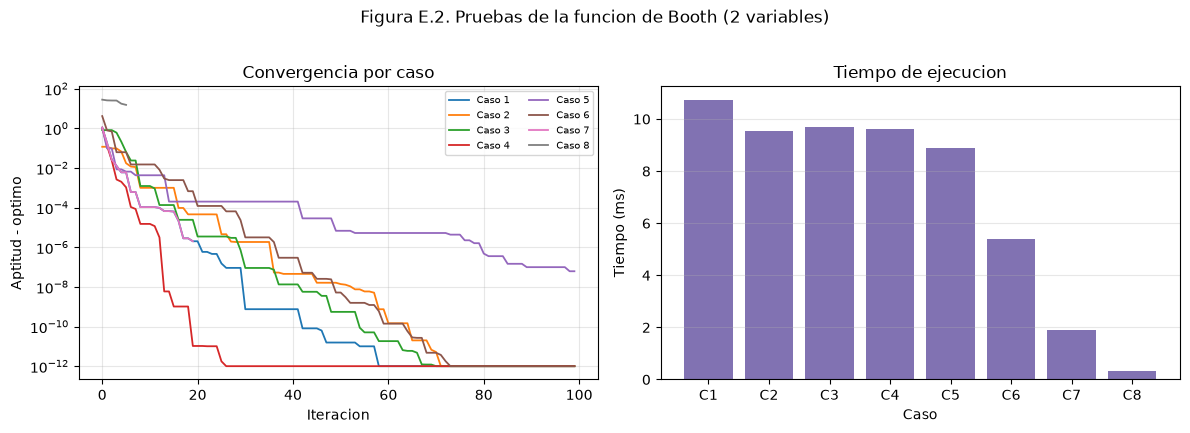

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# Convergencia: distancia entre la aptitud del mejor global y el optimo, en escala log
for numero, historial in historiales_e.items():
    axes[0].semilogy(np.maximum(historial - f_optimo_e, 1e-12), lw=1.3, label=f"Caso {numero}")
axes[0].set_xlabel("Iteracion")
axes[0].set_ylabel("Aptitud - optimo")
axes[0].set_title("Convergencia por caso")
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(alpha=0.3)

# Tiempo de ejecucion de cada caso
axes[1].bar([f"C{n}" for n, *_ in casos_e], tabla_e["Tiempo (ms)"], color="#8172B2")
axes[1].set_xlabel("Caso")
axes[1].set_ylabel("Tiempo (ms)")
axes[1].set_title("Tiempo de ejecucion")
axes[1].grid(alpha=0.3, axis="y")

fig.suptitle("Figura E.2. Pruebas de la funcion de Booth (2 variables)", y=1.02)
fig.tight_layout()
plt.show()

**Análisis:** Igual que con el problema lineal de la sección 3.4 y con la función de clase en 1 variable, Booth es convexa (un solo mínimo, sin trampas) y el PSO la resuelve sin problema en los casos 1 a 7, sin importar mucho la atracción, la inercia, la población (caso 6, 30 partículas) o las iteraciones (caso 7, 20 iteraciones): siempre llega a $(1, 3)$ con $f\approx 0$. El caso 8, que combina población e iteraciones mínimas (6 y 6) con atracción e inercia bajas, es el único que se estanca, con $f\approx 15.42$ lejos de $0$: con tan pocas partículas y pasos el enjambre ni siquiera alcanza a acercarse al fondo del paraboloide antes de que se acaben las iteraciones. El tiempo de ejecución, igual que en las demás secciones, depende sobre todo de población $\times$ iteraciones (de 10.7 ms en el caso base a 0.3 ms en el caso 8) y no de los coeficientes de atracción ni de la inercia.

### 2.5 Función extra: Himmelblau (2 variables)

#### 2.5.1 Definición del problema

**Himmelblau (función extra, tomada del listado de funciones de prueba para optimización).**
Minimizar

$$f(x, y) = (x^2 + y - 11)^2 + (x + y^2 - 7)^2, \qquad x, y \in [-5, 5]$$

A diferencia de Booth, no tiene un solo mínimo global sino **cuatro**, todos con $f=0$:
$(3,\ 2)$, $(-2.805118,\ 3.131312)$, $(-3.779310,\ -3.283186)$ y $(3.584428,\ -1.848126)$.
Entre esos mínimos hay varias crestas y un máximo local, lo que la hace más interesante que
Booth para ver si el PSO se estanca en dimensión 2.

#### 2.5.2 Pseudocódigo

```
INICIO
  Definir num_pob, c1, c2, phi0, generaciones y los limites del dominio [-5, 5]
  Inicializar x1p, x2p aleatorios en [-5, 5]
  Inicializar vx1, vx2 en cero
  x1pg, x2pg <- 0 con fxpg = infinito
  x1pL, x2pL <- posicion inicial de cada particula, fxpL = infinito

  PARA k = 1 HASTA generaciones
      vx1 <- phi0*vx1 + c1*rand*(x1pL - x1p) + c2*rand*(x1pg - x1p)
      vx2 <- phi0*vx2 + c1*rand*(x2pL - x2p) + c2*rand*(x2pg - x2p)
      x1p <- recortar(x1p + vx1, [-5, 5])
      x2p <- recortar(x2p + vx2, [-5, 5])

      fx <- (x1p^2 + x2p - 11)^2 + (x1p + x2p^2 - 7)^2

      SI min(fx) < fxpg -> actualizar mejor global (x1pg, x2pg, fxpg)
      Actualizar mejor local de las particulas que mejoraron
      Dibujar el contorno de la funcion, las particulas y el mejor global
  FIN PARA

  Imprimir x1pg, x2pg y fxpg
FIN
```

La única diferencia respecto al código de la sección 2.3 es que aquí sí se recorta la posición
al dominio $[-5, 5]$ en cada iteración, igual que se hizo con Ackley en la sección 1.5: fuera de
ese rango la función sigue creciendo y no aporta nada dejar que las partículas se salgan.

#### 2.5.3 Código comentado

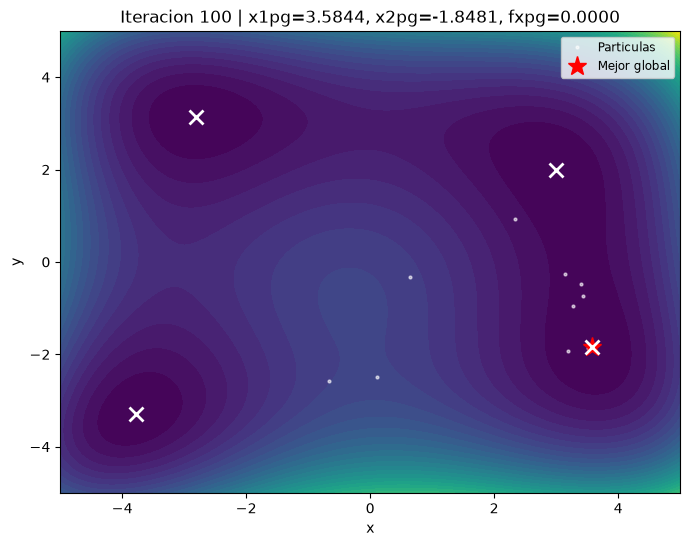

x1pg = 3.5844
x2pg = -1.8481
fxpg = 0.0000


In [5]:
# --- PSO 2 variables: funcion de Himmelblau + graficacion del estado final ---

# Funcion objetivo (Himmelblau)
def f_himmelblau(x1, x2):
    return (x1**2 + x2 - 11)**2 + (x1 + x2**2 - 7)**2

x_min_f, x_max_f = -5, 5

# Malla para dibujar el contorno de la funcion
gx_f = np.linspace(x_min_f, x_max_f, 300)
gy_f = np.linspace(x_min_f, x_max_f, 300)
malla_x_f, malla_y_f = np.meshgrid(gx_f, gy_f)
malla_z_f = f_himmelblau(malla_x_f, malla_y_f)

# Los cuatro minimos globales conocidos (todos con f = 0)
optimos_f = [(3.0, 2.0), (-2.805118, 3.131312), (-3.779310, -3.283186), (3.584428, -1.848126)]

# --- Parametros del enjambre (mismos que en 2.3) ---
num_pob = 500
c1 = 0.5
c2 = 0.5
phi0 = 0.7

np.random.seed(5)   # semilla fija para poder repetir esta corrida

# Inicializacion de la poblacion
x1p = (x_max_f - x_min_f) * np.random.rand(num_pob) + x_min_f
x2p = (x_max_f - x_min_f) * np.random.rand(num_pob) + x_min_f
x1pg, x2pg = 0, 0
x1pL, x2pL = np.copy(x1p), np.copy(x2p)

fxpg = np.inf
fxpL = np.ones(num_pob) * fxpg
vx1 = np.zeros(num_pob)
vx2 = np.zeros(num_pob)

fig, ax = plt.subplots(figsize=(8, 6))

for k in range(100):
    # Ecuaciones de movimiento
    vx1 = phi0*vx1 + c1*np.random.rand(num_pob)*(x1pL - x1p) + c2*np.random.rand(num_pob)*(x1pg - x1p)
    vx2 = phi0*vx2 + c1*np.random.rand(num_pob)*(x2pL - x2p) + c2*np.random.rand(num_pob)*(x2pg - x2p)
    x1p = np.clip(x1p + vx1, x_min_f, x_max_f)   # se mantiene dentro del dominio
    x2p = np.clip(x2p + vx2, x_min_f, x_max_f)

    # Evaluacion del desempeño de cada particula
    fx = f_himmelblau(x1p, x2p)
    val = np.min(fx)
    ind = np.argmin(fx)

    # Actualizar mejor global
    if val < fxpg:
        fxpg = val
        x1pg, x2pg = x1p[ind], x2p[ind]

    # Actualizar mejor local (vectorizado)
    mejores = fx < fxpL
    fxpL[mejores] = fx[mejores]
    x1pL[mejores] = x1p[mejores]
    x2pL[mejores] = x2p[mejores]

    # Graficar estado de la iteracion
    ax.clear()
    ax.contourf(malla_x_f, malla_y_f, malla_z_f, levels=40, cmap='viridis')
    ax.plot(x1p, x2p, 'w.', markersize=4, alpha=0.6, label='Particulas')
    ax.plot(x1pg, x2pg, 'r*', markersize=14, label='Mejor global')
    for ox, oy in optimos_f:
        ax.plot(ox, oy, 'wx', markersize=10, mew=2)
    ax.set_xlim([x_min_f, x_max_f])
    ax.set_ylim([x_min_f, x_max_f])
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'Iteracion {k+1} | x1pg={x1pg:.4f}, x2pg={x2pg:.4f}, fxpg={fxpg:.4f}')
    ax.legend(loc='upper right', fontsize='small')

plt.show()

print(f'x1pg = {x1pg:.4f}')
print(f'x2pg = {x2pg:.4f}')
print(f'fxpg = {fxpg:.4f}')

Estado final del enjambre. Las equis blancas son los cuatro mínimos globales; el
enjambre converge a uno solo de ellos (el más cercano al punto de partida promedio), no a los
cuatro a la vez.

#### 2.5.4 Pruebas y resultados

Mismas 8 combinaciones de parámetros que en la sección 2.4, ahora sobre Himmelblau. Como los
cuatro mínimos valen $f=0$, se considera que llegó a **un** óptimo global si $f(x)$ queda a
menos de 0.5 de $0$, sin importar a cuál de los cuatro haya convergido (se reporta también el
punto $(x,y)$ encontrado).

In [6]:
def pso_himmelblau(num_pob, c1, c2, phi0, generaciones, semilla=5):
    """Mismo PSO de la celda anterior, sin graficación, para poder repetirlo con distintos parámetros."""
    np.random.seed(semilla)

    x1p = (x_max_f - x_min_f) * np.random.rand(num_pob) + x_min_f
    x2p = (x_max_f - x_min_f) * np.random.rand(num_pob) + x_min_f
    x1pg, x2pg = 0, 0
    x1pL, x2pL = np.copy(x1p), np.copy(x2p)
    fxpg = np.inf
    fxpL = np.ones(num_pob) * fxpg
    vx1, vx2 = np.zeros(num_pob), np.zeros(num_pob)

    historial = []
    inicio = time.perf_counter()

    for k in range(generaciones):
        vx1 = phi0*vx1 + c1*np.random.rand(num_pob)*(x1pL - x1p) + c2*np.random.rand(num_pob)*(x1pg - x1p)
        vx2 = phi0*vx2 + c1*np.random.rand(num_pob)*(x2pL - x2p) + c2*np.random.rand(num_pob)*(x2pg - x2p)
        x1p = np.clip(x1p + vx1, x_min_f, x_max_f)
        x2p = np.clip(x2p + vx2, x_min_f, x_max_f)

        fx = f_himmelblau(x1p, x2p)
        val, ind = np.min(fx), np.argmin(fx)
        if val < fxpg:
            fxpg, x1pg, x2pg = val, x1p[ind], x2p[ind]

        mejores = fx < fxpL
        fxpL[mejores] = fx[mejores]
        x1pL[mejores] = x1p[mejores]
        x2pL[mejores] = x2p[mejores]

        historial.append(fxpg)

    tiempo = time.perf_counter() - inicio
    return x1pg, x2pg, fxpg, np.array(historial), tiempo

casos_f = [
    (1, 0.5, 0.5, 0.7, 500, 100, "Base (codigo de clase)"),
    (2, 1.5, 1.5, 0.7, 500, 100, "Atraccion alta"),
    (3, 0.1, 0.1, 0.7, 500, 100, "Atraccion baja"),
    (4, 0.5, 0.5, 0.4, 500, 100, "Inercia baja"),
    (5, 0.5, 0.5, 0.9, 500, 100, "Inercia alta"),
    (6, 0.5, 0.5, 0.7, 30, 100, "Poblacion pequeña"),
    (7, 0.5, 0.5, 0.7, 500, 20, "Pocas iteraciones"),
    (8, 0.15, 0.15, 0.2, 6, 6, "Poblacion e iteraciones extremas"),
]

f_optimo_f = 0   # los cuatro minimos globales conocidos valen f = 0

filas_f, historiales_f = [], {}

for numero, c1_p, c2_p, phi_p, pob_p, gen_p, descripcion in casos_f:
    x1_best, x2_best, f_best, historial, tiempo = pso_himmelblau(pob_p, c1_p, c2_p, phi_p, gen_p)
    historiales_f[numero] = historial
    filas_f.append({
        "Caso": numero, "Descripcion": descripcion,
        "c1": c1_p, "c2": c2_p, "phi0": phi_p,
        "Poblacion": pob_p, "Iteraciones": gen_p,
        "x": round(x1_best, 4), "y": round(x2_best, 4),
        "f(x,y)": round(f_best, 4), "Error": round(abs(f_best - f_optimo_f), 4),
        "Tiempo (ms)": round(tiempo * 1000, 2),
        "Resultado": "Optimo global" if abs(f_best - f_optimo_f) <= 0.5 else "Se estanco",
    })

tabla_f = pd.DataFrame(filas_f)
tabla_f

,Caso,Descripcion,c1,c2,phi0,Poblacion,Iteraciones,x,y,"f(x,y)",Error,Tiempo (ms),Resultado
0,1,Base (codigo de clase),0.50,0.50,0.7,500,100,3.5844,-1.8481,0.0000,0.0000,12.23,Optimo global
1,2,Atraccion alta,1.50,1.50,0.7,500,100,3.5844,-1.8481,0.0000,0.0000,12.62,Optimo global
2,3,Atraccion baja,0.10,0.10,0.7,500,100,3.5844,-1.8481,0.0000,0.0000,11.41,Optimo global
3,4,Inercia baja,0.50,0.50,0.4,500,100,3.5844,-1.8481,0.0000,0.0000,11.09,Optimo global
4,5,Inercia alta,0.50,0.50,0.9,500,100,3.5845,-1.8482,0.0000,0.0000,10.13,Optimo global
5,6,Poblacion pequeña,0.50,0.50,0.7,30,100,3.0000,2.0000,0.0000,0.0000,6.71,Optimo global
6,7,Pocas iteraciones,0.50,0.50,0.7,500,20,3.5829,-1.8479,0.0001,0.0001,2.23,Optimo global
7,8,Poblacion e iteraciones extremas,0.15,0.15,0.2,6,6,3.4355,-2.0504,1.9661,1.9661,0.38,Se estanco


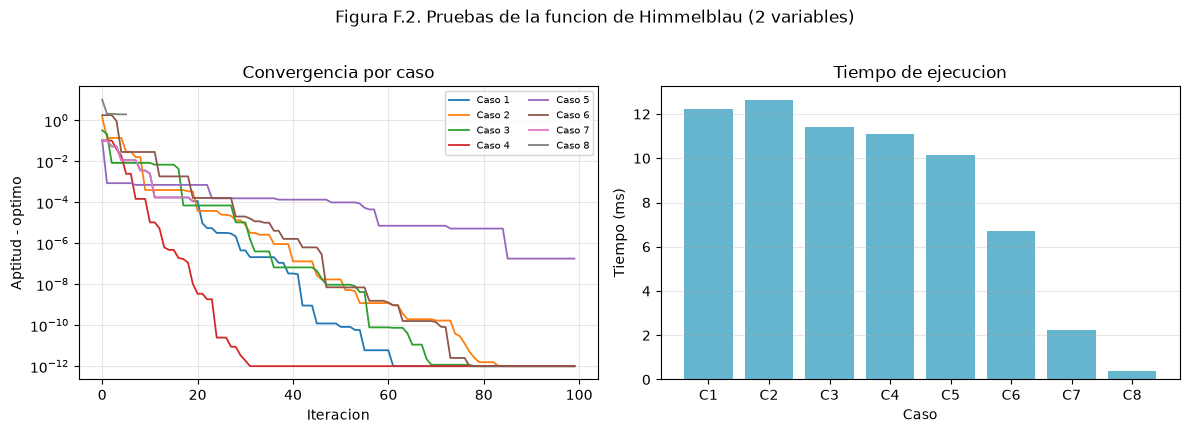

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

for numero, historial in historiales_f.items():
    axes[0].semilogy(np.maximum(historial - f_optimo_f, 1e-12), lw=1.3, label=f"Caso {numero}")
axes[0].set_xlabel("Iteracion")
axes[0].set_ylabel("Aptitud - optimo")
axes[0].set_title("Convergencia por caso")
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(alpha=0.3)

axes[1].bar([f"C{n}" for n, *_ in casos_f], tabla_f["Tiempo (ms)"], color="#64B5CD")
axes[1].set_xlabel("Caso")
axes[1].set_ylabel("Tiempo (ms)")
axes[1].set_title("Tiempo de ejecucion")
axes[1].grid(alpha=0.3, axis="y")

fig.suptitle("Figura F.2. Pruebas de la funcion de Himmelblau (2 variables)", y=1.02)
fig.tight_layout()
plt.show()

**Análisis:** En Himmelblau los casos 1 a 7 también llegan a un óptimo global ($f\approx 0$), pero aquí aparece algo que no se veía en Booth: como hay cuatro mínimos igual de buenos, el enjambre no siempre converge al mismo. En los casos 1 a 5 y 7 (500 partículas) el mejor global termina en $(3.5844,\ -1.8481)$; en el caso 6, con solo 30 partículas, termina en $(3,\ 2)$, un mínimo global distinto pero igual de válido ($f=0$ en ambos). Es decir que con menos partículas el enjambre "elige" un mínimo distinto según qué tan cerca haya arrancado alguna partícula de cada uno, no porque uno sea mejor que otro. El caso 8 (6 partículas, 6 iteraciones, atracción e inercia bajas) vuelve a ser el único que se estanca, con $f\approx 1.97$, en un punto que no coincide con ninguno de los cuatro mínimos conocidos: aquí sí se nota el efecto de la multimodalidad, porque con tan pocos recursos el enjambre puede quedar atrapado en la zona entre mínimos sin decidirse por ninguno. En general el patrón se repite: el tiempo de ejecución depende de población $\times$ iteraciones y el estancamiento solo aparece en la combinación extrema de muy pocas partículas y pocas iteraciones.

## 3. PSO con 2 variables y restricciones

### 3.1 Definición del problema

**Código de clase.** Maximizar

$$Z = 16.9175\,X_1 + 22.715\,X_2$$

sujeto a $100X_1+150X_2 \le 12000$, $20X_1+30X_2 \le 3000$, $25X_1+40X_2 \le 3000$,
$X_2 \ge 30$, $X_1 \ge 0$, $X_2 \ge 0$.

Es lineal, así que el óptimo está en un vértice y se puede verificar a mano: la segunda
restricción es redundante y el mejor vértice es la intersección de $X_2=30$ con
$25X_1+40X_2=3000$, o sea $X_1 = 72$, $X_2 = 30$, $Z = 1899.51$.


### 3.3 Pseudocódigo

```
INICIO
  Definir num_pob, c1, c2, phi0 y generaciones
  Inicializar x1p, x2p aleatorios
  Inicializar vx1, vx2 en cero
  mejor_global <- (0, 0) con fxpg = infinito
  mejor_local  <- posicion inicial de cada particula

  PARA k = 1 HASTA generaciones
      vx1 <- phi0*vx1 + c1*rand*(x1pL - x1p) + c2*rand*(x1pg - x1p)
      vx2 <- phi0*vx2 + c1*rand*(x2pL - x2p) + c2*rand*(x2pg - x2p)
      x1p <- x1p + vx1
      x2p <- x2p + vx2

      z  <- -(16.9175*x1p + 22.715*x2p)
      p1..p6 <- max(0, violacion de cada restriccion)
      fx <- z + 1e6 * (p1^2 + ... + p6^2)

      SI min(fx) < fxpg -> actualizar mejor global
      Actualizar mejor local de las particulas que mejoraron
      Dibujar region factible, particulas y mejor global
  FIN PARA

  Imprimir X1, X2 y Z del mejor global
FIN
```

### 3.3 Código 3 de clase

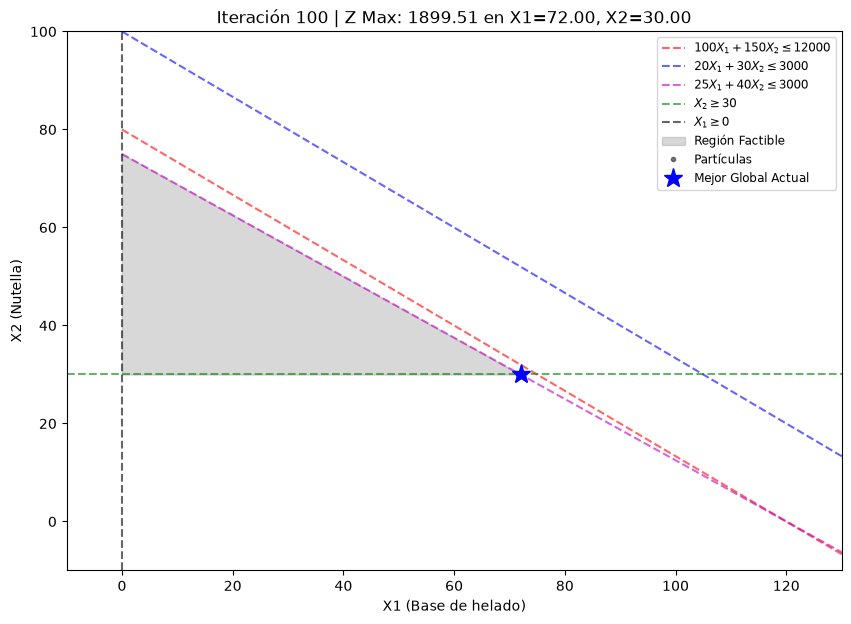

--- RESULTADO ÓPTIMO ENCONTRADO ---
X1 (Cantidad de Base): 72.0000 ml
X2 (Cantidad de Nutella): 30.0000 gr
Ganancia Máxima (Z): 1899.5099


In [2]:
np.random.seed(5)   # semilla fija para poder repetir exactamente esta corrida

# Parámetros del Enjambre
num_pob = 300          # cantidad de partículas
c1 = 0.5               # atracción hacia el mejor local (componente cognitiva)
c2 = 0.5               # atracción hacia el mejor global (componente social)
phi0 = 0.7             # Inercia: qué tanto conserva la partícula su velocidad anterior
generaciones = 100     # número de iteraciones

# Inicialización de población
x1p = np.random.uniform(0, 1000, num_pob)
x2p = np.random.uniform(0, 1000, num_pob)

# Variables para el mejor global y local
x1pg, x2pg = 0, 0      # posición del mejor global
fxpg = np.inf          # aptitud del mejor global: arranca en infinito para que cualquiera gane

x1pL = np.copy(x1p)    # mejor posición histórica de cada partícula
x2pL = np.copy(x2p)
fxpL = np.ones(num_pob) * fxpg

# Velocidades iniciales
vx1 = np.zeros(num_pob)
vx2 = np.zeros(num_pob)

# Preparación de la gráfica (sin animacion: se muestra la figura de la ultima iteracion)
fig, ax = plt.subplots(figsize=(10, 7))

# Rango de X para dibujar las líneas de las restricciones
x_line = np.linspace(0, 150, 400)

for k in range(generaciones):
    # Ecuaciones de movimiento: inercia + jalón al mejor local + jalón al mejor global
    vx1 = phi0 * vx1 + c1 * np.random.rand(num_pob) * (x1pL - x1p) + c2 * np.random.rand(num_pob) * (x1pg - x1p)
    vx2 = phi0 * vx2 + c1 * np.random.rand(num_pob) * (x2pL - x2p) + c2 * np.random.rand(num_pob) * (x2pg - x2p)

    # Nueva posición de cada partícula
    x1p = x1p + vx1
    x2p = x2p + vx2

    # Función Objetivo a MAXIMIZAR (negativa para que el PSO la minimice)
    z = -(16.9175 * x1p + 22.715 * x2p)

    # --- RESTRICCIONES (cada una escrita como g <= 0 y medida con max(0, g)) ---
    p1 = np.maximum(0, 100*x1p + 150*x2p - 12000)
    p2 = np.maximum(0, 20*x1p + 30*x2p - 3000)
    p3 = np.maximum(0, 25*x1p + 40*x2p - 3000)
    p4 = np.maximum(0, 30 - x2p)  # 0 X1 + 1 X2 >= 30
    p5 = np.maximum(0, -x1p)      # X1 >= 0
    p6 = np.maximum(0, -x2p)      # X2 >= 0

    # Función fitness con castigo altísimo (1e6) si violan restricciones
    fx = z + 1e6 * (p1**2 + p2**2 + p3**2 + p4**2 + p5**2 + p6**2)

    val = np.min(fx)    # mejor aptitud de esta generación
    ind = np.argmin(fx) # índice de la partícula que la tiene

    # Actualizar mejor global
    if val < fxpg:
        fxpg = val
        x1pg = x1p[ind]
        x2pg = x2p[ind]

    # Actualizar mejor local: solo las partículas que mejoraron su propio récord
    mejores = fx < fxpL
    fxpL[mejores] = fx[mejores]
    x1pL[mejores] = x1p[mejores]
    x2pL[mejores] = x2p[mejores]

    # ---------- GRAFICACIÓN ----------
    ax.clear()

    # 1. Dibujar las líneas de restricción, despejadas en función de X2
    y1 = (12000 - 100*x_line) / 150
    y2 = (3000 - 20*x_line) / 30
    y3 = (3000 - 25*x_line) / 40

    ax.plot(x_line, y1, 'r--', alpha=0.6, label=r"$100X_1 + 150X_2 \leq 12000$")
    ax.plot(x_line, y2, 'b--', alpha=0.6, label=r"$20X_1 + 30X_2 \leq 3000$")
    ax.plot(x_line, y3, 'm--', alpha=0.6, label=r"$25X_1 + 40X_2 \leq 3000$")
    ax.axhline(30, color='g', linestyle='--', alpha=0.6, label=r"$X_2 \geq 30$")
    ax.axvline(0, color='k', linestyle='--', alpha=0.6, label=r"$X_1 \geq 0$")

    # 2. Sombrear la región factible
    y_upper = np.minimum(y1, np.minimum(y2, y3)) # El techo es la restricción más estricta
    ax.fill_between(x_line, 30, y_upper, where=(y_upper >= 30), color='gray', alpha=0.3, label='Región Factible')

    # 3. Dibujar partículas y mejor global
    ax.plot(x1p, x2p, 'k.', alpha=0.5, label='Partículas')
    ax.plot(x1pg, x2pg, 'b*', markersize=14, label='Mejor Global Actual')

    # 4. Configuración del lienzo
    ax.set_xlim([-10, 130])
    ax.set_ylim([-10, 100])
    ax.set_xlabel('X1 (Base de helado)')
    ax.set_ylabel('X2 (Nutella)')
    ax.set_title(f'Iteración {k+1} | Z Max: {-fxpg:.2f} en X1={x1pg:.2f}, X2={x2pg:.2f}')
    ax.legend(loc='upper right', fontsize='small')

plt.show()

print("--- RESULTADO ÓPTIMO ENCONTRADO ---")
print(f"X1 (Cantidad de Base): {x1pg:.4f} ml")
print(f"X2 (Cantidad de Nutella): {x2pg:.4f} gr")
print(f"Ganancia Máxima (Z): {-fxpg:.4f}")

Estado final del enjambre. Las partículas se concentran en el vértice
$(72, 30)$, que es la esquina derecha de la región factible sombreada.

### 3.4 Pruebas y resultados

Se repite el mismo algoritmo, sin la parte de graficación, con 8 combinaciones de parámetros:
atracción ($c_1$, $c_2$), inercia ($\phi_0$), población e iteraciones. El caso 1 es el del
código de clase. Se considera que llegó al óptimo global si $Z$ queda a menos de 0.5 de
1899.51.

In [3]:
def pso_produccion(num_pob, c1, c2, phi0, generaciones, semilla=5):
    """Mismo PSO de la celda anterior, sin graficación, para poder repetirlo con distintos parámetros."""
    np.random.seed(semilla)

    x1p = np.random.uniform(0, 1000, num_pob)
    x2p = np.random.uniform(0, 1000, num_pob)

    x1pg, x2pg = 0, 0
    fxpg = np.inf
    x1pL, x2pL = np.copy(x1p), np.copy(x2p)
    fxpL = np.ones(num_pob) * fxpg
    vx1, vx2 = np.zeros(num_pob), np.zeros(num_pob)

    historial = []
    inicio = time.perf_counter()

    for k in range(generaciones):
        vx1 = phi0 * vx1 + c1 * np.random.rand(num_pob) * (x1pL - x1p) + c2 * np.random.rand(num_pob) * (x1pg - x1p)
        vx2 = phi0 * vx2 + c1 * np.random.rand(num_pob) * (x2pL - x2p) + c2 * np.random.rand(num_pob) * (x2pg - x2p)
        x1p = x1p + vx1
        x2p = x2p + vx2

        z = -(16.9175 * x1p + 22.715 * x2p)
        p1 = np.maximum(0, 100*x1p + 150*x2p - 12000)
        p2 = np.maximum(0, 20*x1p + 30*x2p - 3000)
        p3 = np.maximum(0, 25*x1p + 40*x2p - 3000)
        p4 = np.maximum(0, 30 - x2p)
        p5 = np.maximum(0, -x1p)
        p6 = np.maximum(0, -x2p)
        fx = z + 1e6 * (p1**2 + p2**2 + p3**2 + p4**2 + p5**2 + p6**2)

        val, ind = np.min(fx), np.argmin(fx)
        if val < fxpg:
            fxpg, x1pg, x2pg = val, x1p[ind], x2p[ind]

        mejores = fx < fxpL
        fxpL[mejores] = fx[mejores]
        x1pL[mejores] = x1p[mejores]
        x2pL[mejores] = x2p[mejores]

        historial.append(fxpg)

    tiempo = time.perf_counter() - inicio
    return x1pg, x2pg, -fxpg, np.array(historial), tiempo

# (numero, c1, c2, phi0, poblacion, iteraciones, descripcion)
casos_a = [
    (1, 0.5, 0.5, 0.7, 300, 100, "Base (codigo de clase)"),
    (2, 1.5, 1.5, 0.7, 300, 100, "Atraccion alta"),
    (3, 0.1, 0.1, 0.7, 300, 100, "Atraccion baja"),
    (4, 0.5, 0.5, 0.4, 300, 100, "Inercia baja"),
    (5, 0.5, 0.5, 0.9, 300, 100, "Inercia alta"),
    (6, 0.5, 0.5, 0.7, 30, 100, "Poblacion pequeña"),
    (7, 0.5, 0.5, 0.7, 300, 20, "Pocas iteraciones"),
    (8, 2.0, 0.5, 0.9, 50, 300, "Poblacion chica, corrida larga"),
]

z_optimo = 1899.51   # optimo analitico del problema

filas_a, historiales_a = [], {}

for numero, c1_p, c2_p, phi_p, pob_p, gen_p, descripcion in casos_a:
    x1_best, x2_best, z_best, historial, tiempo = pso_produccion(pob_p, c1_p, c2_p, phi_p, gen_p)
    historiales_a[numero] = historial
    filas_a.append({
        "Caso": numero, "Descripcion": descripcion,
        "c1": c1_p, "c2": c2_p, "phi0": phi_p,
        "Poblacion": pob_p, "Iteraciones": gen_p,
        "X1": round(x1_best, 4), "X2": round(x2_best, 4),
        "Z": round(z_best, 4), "Error": round(abs(z_best - z_optimo), 4),
        "Tiempo (ms)": round(tiempo * 1000, 2),
        "Resultado": "Optimo global" if abs(z_best - z_optimo) <= 0.5 else "Se estanco",
    })

tabla_a = pd.DataFrame(filas_a)
tabla_a

,Caso,Descripcion,c1,c2,phi0,Poblacion,Iteraciones,X1,X2,Z,Error,Tiempo (ms),Resultado
0,1,Base (codigo de clase),0.5,0.5,0.7,300,100,72.0000,30.0000,1899.5099,0.0001,53.87,Optimo global
1,2,Atraccion alta,1.5,1.5,0.7,300,100,71.9913,30.0052,1899.4813,0.0287,21.09,Optimo global
2,3,Atraccion baja,0.1,0.1,0.7,300,100,71.9999,30.0000,1899.5099,0.0001,15.21,Optimo global
3,4,Inercia baja,0.5,0.5,0.4,300,100,72.0000,30.0000,1899.5099,0.0001,14.54,Optimo global
4,5,Inercia alta,0.5,0.5,0.9,300,100,71.6205,30.2337,1898.3988,1.1112,13.27,Se estanco
5,6,Poblacion pequeña,0.5,0.5,0.7,30,100,47.0335,45.6035,1831.5736,67.9364,8.34,Se estanco
6,7,Pocas iteraciones,0.5,0.5,0.7,300,20,69.8080,31.3052,1892.0762,7.4338,2.27,Se estanco
7,8,"Poblacion chica, corrida larga",2.0,0.5,0.9,50,300,71.2064,30.4235,1895.7032,3.8068,46.83,Se estanco


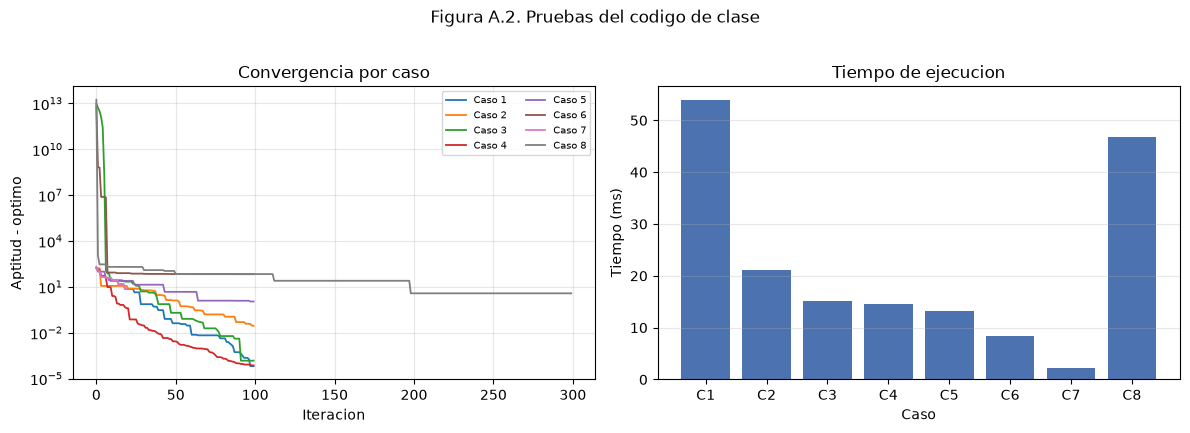

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# Convergencia: distancia entre la aptitud del mejor global y el optimo, en escala log
for numero, historial in historiales_a.items():
    axes[0].semilogy(np.maximum(historial + z_optimo, 1e-12), lw=1.3, label=f"Caso {numero}")
axes[0].set_xlabel("Iteracion")
axes[0].set_ylabel("Aptitud - optimo")
axes[0].set_title("Convergencia por caso")
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(alpha=0.3)

# Tiempo de ejecucion de cada caso
axes[1].bar([f"C{n}" for n, *_ in casos_a], tabla_a["Tiempo (ms)"], color="#4C72B0")
axes[1].set_xlabel("Caso")
axes[1].set_ylabel("Tiempo (ms)")
axes[1].set_title("Tiempo de ejecucion")
axes[1].grid(alpha=0.3, axis="y")

fig.suptitle("Figura A.2. Pruebas del codigo de clase", y=1.02)
fig.tight_layout()
plt.show()

**Análisis:** En un problema lineal con restricciones el PSO es robusto: llega
al óptimo global con casi cualquier configuración razonable, y lo que decide es tener población
e iteraciones suficientes, no el ajuste fino de la inercia o de los coeficientes de
atracción.

## 3.5 Función Townsend modificada

### 3.5.1 Definición del problema

**Townsend modificada (función extra con restricción).** Minimizar

$$f(x,y) = -\left[\cos\big((x-0.1)y\big)\right]^2 - x\,\sin(3x+y)$$

sujeta a

$$x^2+y^2 < \left[2\cos t - \tfrac12\cos 2t - \tfrac14\cos 3t - \tfrac18\cos 4t\right]^2 + \left[2\sin t\right]^2,
\qquad t = \operatorname{atan2}(x,y)$$

con $-2.25 \le x \le 2.5$ y $-2.5 \le y \le 1.75$. Óptimo global conocido:
$f(2.0052938, 1.1944509) = -2.0239884$. 

## 3.5.2 Pseudocódigo

```
INICIO
  Definir num_pob, c1, c2, phi0, generaciones y los limites del dominio
  Inicializar x1p, x2p aleatorios dentro del dominio
  Inicializar vx1, vx2 en cero
  mejor_global <- particula con menor fitness de la poblacion inicial
  mejor_local  <- posicion inicial de cada particula

  PARA k = 1 HASTA generaciones
      vx1 <- phi0*vx1 + c1*rand*(x1pL - x1p) + c2*rand*(x1pg - x1p)
      vx2 <- phi0*vx2 + c1*rand*(x2pL - x2p) + c2*rand*(x2pg - x2p)
      x1p <- recortar(x1p + vx1, limites en x)
      x2p <- recortar(x2p + vx2, limites en y)

      z  <- -cos((x1p - 0.1)*x2p)^2 - x1p*sin(3*x1p + x2p)
      t  <- atan2(x1p, x2p)
      r2 <- (2cos t - 0.5cos 2t - 0.25cos 3t - 0.125cos 4t)^2 + (2 sin t)^2
      p1 <- max(0, x1p^2 + x2p^2 - r2)
      fx <- z + 1e6 * p1^2

      SI min(fx) < fxpg -> actualizar mejor global
      Actualizar mejor local de las particulas que mejoraron
      Dibujar region factible, particulas y mejor global
  FIN PARA

  Imprimir x, y y f del mejor global
FIN
```

Dos diferencias respecto al código de la Parte A, y por qué:

- El mejor global se toma de la población inicial en lugar de arrancar en $(0,0)$ con
  `fxpg = inf`. Aquí el origen es un punto cualquiera del dominio y arrastrar todo el enjambre
  hacia él en la primera iteración sesga la búsqueda.
- La posición se recorta al dominio. La función y la restricción solo están definidas en ese
  rectángulo, y sin el recorte la penalización al cuadrado se dispara.

### 3.5.3 Código

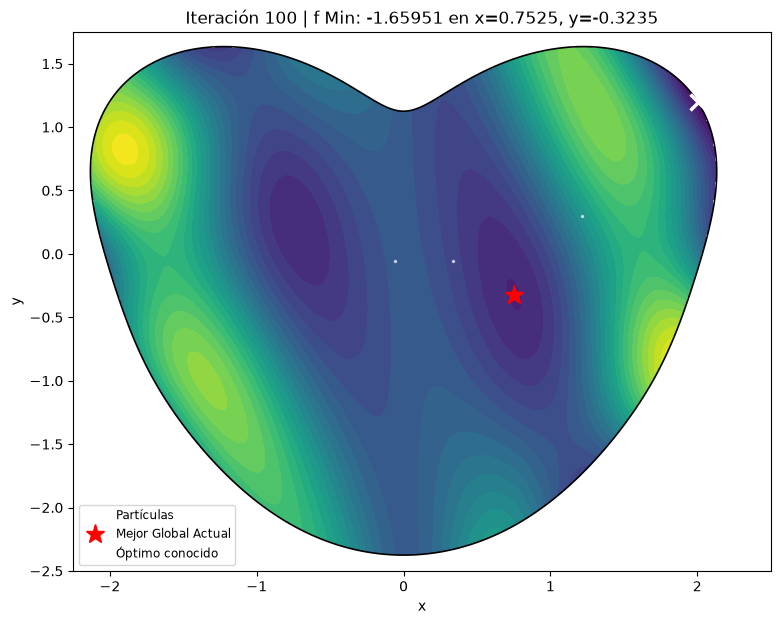

--- RESULTADO ÓPTIMO ENCONTRADO ---
x: 0.752526
y: -0.323520
f(x, y): -1.659511
Óptimo conocido: x=2.0052938, y=1.1944509, f=-2.0239884


In [5]:
np.random.seed(5)   # semilla fija para poder repetir esta corrida

# Parámetros del enjambre
num_pob_b = 300
c1_b = 0.5             # atracción al mejor local
c2_b = 0.5             # atracción al mejor global
phi0_b = 0.7           # inercia
generaciones_b = 100

# Límites del dominio de la función Townsend modificada
x_min, x_max = -2.25, 2.5
y_min, y_max = -2.5, 1.75

# Inicialización de la población dentro del dominio
x1p_b = np.random.uniform(x_min, x_max, num_pob_b)
x2p_b = np.random.uniform(y_min, y_max, num_pob_b)

# Velocidades iniciales
vx1_b = np.zeros(num_pob_b)
vx2_b = np.zeros(num_pob_b)


def fitness_townsend(x1p, x2p):
    """Devuelve (fitness penalizado, valor real de f). La restricción se castiga con 1e6."""
    # Función objetivo a MINIMIZAR
    z = -(np.cos((x1p - 0.1) * x2p))**2 - x1p * np.sin(3 * x1p + x2p)

    # Restricción: x^2 + y^2 < r(t)^2, con t = atan2(x, y) en ese orden
    t = np.arctan2(x1p, x2p)
    rx = 2*np.cos(t) - 0.5*np.cos(2*t) - 0.25*np.cos(3*t) - 0.125*np.cos(4*t)
    ry = 2*np.sin(t)
    p1 = np.maximum(0, x1p**2 + x2p**2 - (rx**2 + ry**2))

    return z + 1e6 * p1**2, z


# Mejores local y global tomados de la población inicial
fx_b, z_b = fitness_townsend(x1p_b, x2p_b)
x1pL_b, x2pL_b, fxpL_b = np.copy(x1p_b), np.copy(x2p_b), np.copy(fx_b)

ind = np.argmin(fx_b)
fxpg_b, x1pg_b, x2pg_b, zpg_b = fx_b[ind], x1p_b[ind], x2p_b[ind], z_b[ind]

# Malla para dibujar el contorno de la función y la frontera de la restricción
gx = np.linspace(x_min, x_max, 400)
gy = np.linspace(y_min, y_max, 400)
malla_x, malla_y = np.meshgrid(gx, gy)
malla_f = -(np.cos((malla_x - 0.1) * malla_y))**2 - malla_x * np.sin(3*malla_x + malla_y)
t_malla = np.arctan2(malla_x, malla_y)
rx_malla = (2*np.cos(t_malla) - 0.5*np.cos(2*t_malla)
            - 0.25*np.cos(3*t_malla) - 0.125*np.cos(4*t_malla))
malla_g = malla_x**2 + malla_y**2 - (rx_malla**2 + (2*np.sin(t_malla))**2)  # <= 0 es factible

# Preparación de la gráfica (sin animacion: se muestra la figura de la ultima iteracion)
fig, ax = plt.subplots(figsize=(9, 7))

for k in range(generaciones_b):
    # Ecuaciones de movimiento
    vx1_b = phi0_b * vx1_b + c1_b * np.random.rand(num_pob_b) * (x1pL_b - x1p_b) + c2_b * np.random.rand(num_pob_b) * (x1pg_b - x1p_b)
    vx2_b = phi0_b * vx2_b + c1_b * np.random.rand(num_pob_b) * (x2pL_b - x2p_b) + c2_b * np.random.rand(num_pob_b) * (x2pg_b - x2p_b)

    # Nueva posición, recortada al dominio de la función
    x1p_b = np.clip(x1p_b + vx1_b, x_min, x_max)
    x2p_b = np.clip(x2p_b + vx2_b, y_min, y_max)

    # Evaluación con penalización
    fx_b, z_b = fitness_townsend(x1p_b, x2p_b)

    val = np.min(fx_b)
    ind = np.argmin(fx_b)

    # Actualizar mejor global
    if val < fxpg_b:
        fxpg_b = val
        x1pg_b = x1p_b[ind]
        x2pg_b = x2p_b[ind]
        zpg_b = z_b[ind]

    # Actualizar mejor local
    mejores = fx_b < fxpL_b
    fxpL_b[mejores] = fx_b[mejores]
    x1pL_b[mejores] = x1p_b[mejores]
    x2pL_b[mejores] = x2p_b[mejores]

    # ---------- GRAFICACIÓN ----------
    ax.clear()

    # 1. Contorno de la función, dibujado solo dentro de la región factible
    ax.contourf(malla_x, malla_y, np.where(malla_g <= 0, malla_f, np.nan),
                levels=30, cmap='viridis')
    # 2. Frontera de la restricción
    ax.contour(malla_x, malla_y, malla_g, levels=[0], colors='k', linewidths=1.2)
    # 3. Partículas, mejor global y óptimo conocido
    ax.plot(x1p_b, x2p_b, 'w.', markersize=3, alpha=0.6, label='Partículas')
    ax.plot(x1pg_b, x2pg_b, 'r*', markersize=14, label='Mejor Global Actual')
    ax.plot(2.0052938, 1.1944509, 'wx', markersize=11, mew=2.5, label='Óptimo conocido')

    # 4. Configuración del lienzo
    ax.set_xlim([x_min, x_max])
    ax.set_ylim([y_min, y_max])
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'Iteración {k+1} | f Min: {zpg_b:.5f} en x={x1pg_b:.4f}, y={x2pg_b:.4f}')
    ax.legend(loc='lower left', fontsize='small')

plt.show()

print("--- RESULTADO ÓPTIMO ENCONTRADO ---")
print(f"x: {x1pg_b:.6f}")
print(f"y: {x2pg_b:.6f}")
print(f"f(x, y): {zpg_b:.6f}")
print("Óptimo conocido: x=2.0052938, y=1.1944509, f=-2.0239884")

Estado final del enjambre sobre el contorno de la función. La zona
coloreada es la región factible y la línea negra es la frontera de la restricción.


### 3.5.3 Pruebas y resultados

Mismas 8 combinaciones de parámetros que en la Parte A, ahora sobre la Townsend modificada. Se
considera que llegó al óptimo global si $f$ queda a menos de $10^{-3}$ de $-2.0239884$.

In [6]:
def pso_townsend(num_pob, c1, c2, phi0, generaciones, semilla=5):
    """Mismo PSO de la celda anterior, sin graficación, para repetirlo con distintos parámetros."""
    np.random.seed(semilla)

    x1p = np.random.uniform(x_min, x_max, num_pob)
    x2p = np.random.uniform(y_min, y_max, num_pob)
    vx1, vx2 = np.zeros(num_pob), np.zeros(num_pob)

    fx, z = fitness_townsend(x1p, x2p)
    x1pL, x2pL, fxpL = np.copy(x1p), np.copy(x2p), np.copy(fx)
    ind = np.argmin(fx)
    fxpg, x1pg, x2pg, zpg = fx[ind], x1p[ind], x2p[ind], z[ind]

    historial = []
    inicio = time.perf_counter()

    for k in range(generaciones):
        vx1 = phi0 * vx1 + c1 * np.random.rand(num_pob) * (x1pL - x1p) + c2 * np.random.rand(num_pob) * (x1pg - x1p)
        vx2 = phi0 * vx2 + c1 * np.random.rand(num_pob) * (x2pL - x2p) + c2 * np.random.rand(num_pob) * (x2pg - x2p)
        x1p = np.clip(x1p + vx1, x_min, x_max)
        x2p = np.clip(x2p + vx2, y_min, y_max)

        fx, z = fitness_townsend(x1p, x2p)
        val, ind = np.min(fx), np.argmin(fx)
        if val < fxpg:
            fxpg, x1pg, x2pg, zpg = val, x1p[ind], x2p[ind], z[ind]

        mejores = fx < fxpL
        fxpL[mejores] = fx[mejores]
        x1pL[mejores] = x1p[mejores]
        x2pL[mejores] = x2p[mejores]

        historial.append(fxpg)

    tiempo = time.perf_counter() - inicio
    return x1pg, x2pg, zpg, np.array(historial), tiempo

casos_b = [
    (1, 0.5, 0.5, 0.7, 300, 100, "Base (mismos parametros de clase)"),
    (2, 1.5, 1.5, 0.7, 300, 100, "Atraccion alta"),
    (3, 0.1, 0.1, 0.7, 300, 100, "Atraccion baja"),
    (4, 0.5, 0.5, 0.4, 300, 100, "Inercia baja"),
    (5, 0.5, 0.5, 0.9, 300, 100, "Inercia alta"),
    (6, 0.5, 0.5, 0.7, 30, 100, "Poblacion pequeña"),
    (7, 0.5, 0.5, 0.7, 300, 20, "Pocas iteraciones"),
    (8, 2.0, 0.5, 0.9, 50, 300, "Poblacion chica, corrida larga"),
]

f_optimo = -2.0239884   # optimo global conocido

filas_b, historiales_b = [], {}

for numero, c1_p, c2_p, phi_p, pob_p, gen_p, descripcion in casos_b:
    x_best, y_best, f_best, historial, tiempo = pso_townsend(pob_p, c1_p, c2_p, phi_p, gen_p)
    historiales_b[numero] = historial
    filas_b.append({
        "Caso": numero, "Descripcion": descripcion,
        "c1": c1_p, "c2": c2_p, "phi0": phi_p,
        "Poblacion": pob_p, "Iteraciones": gen_p,
        "x": round(x_best, 4), "y": round(y_best, 4),
        "f": round(f_best, 6), "Error": round(abs(f_best - f_optimo), 6),
        "Tiempo (ms)": round(tiempo * 1000, 2),
        "Resultado": "Optimo global" if abs(f_best - f_optimo) <= 1e-2 else "Se estanco",
    })

tabla_b = pd.DataFrame(filas_b)
tabla_b

,Caso,Descripcion,c1,c2,phi0,Poblacion,Iteraciones,x,y,f,Error,Tiempo (ms),Resultado
0,1,Base (mismos parametros de clase),0.5,0.5,0.7,300,100,0.7525,-0.3235,-1.659511,0.364477,61.94,Se estanco
1,2,Atraccion alta,1.5,1.5,0.7,300,100,2.0056,1.1939,-2.023971,0.000017,29.44,Optimo global
2,3,Atraccion baja,0.1,0.1,0.7,300,100,2.0029,1.1987,-2.023897,0.000091,17.77,Optimo global
3,4,Inercia baja,0.5,0.5,0.4,300,100,0.7525,-0.3235,-1.659511,0.364477,29.48,Se estanco
4,5,Inercia alta,0.5,0.5,0.9,300,100,0.7525,-0.3235,-1.659511,0.364477,18.03,Se estanco
5,6,Poblacion pequeña,0.5,0.5,0.7,30,100,2.0160,1.1745,-2.022037,0.001952,26.67,Optimo global
6,7,Pocas iteraciones,0.5,0.5,0.7,300,20,0.7526,-0.3236,-1.659511,0.364477,5.68,Se estanco
7,8,"Poblacion chica, corrida larga",2.0,0.5,0.9,50,300,2.0002,1.2036,-2.023554,0.000434,35.97,Optimo global


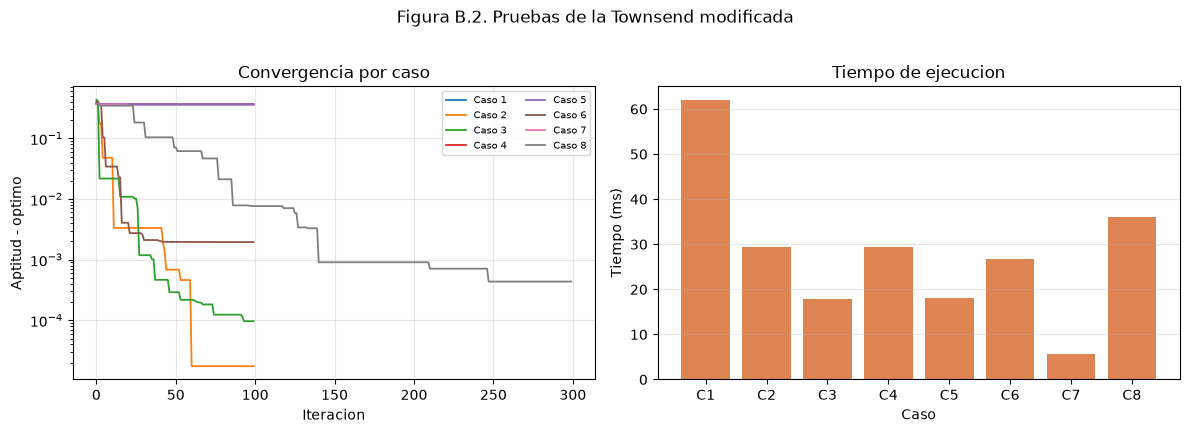

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

for numero, historial in historiales_b.items():
    axes[0].semilogy(np.maximum(historial - f_optimo, 1e-12), lw=1.3, label=f"Caso {numero}")
axes[0].set_xlabel("Iteracion")
axes[0].set_ylabel("Aptitud - optimo")
axes[0].set_title("Convergencia por caso")
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(alpha=0.3)

axes[1].bar([f"C{n}" for n, *_ in casos_b], tabla_b["Tiempo (ms)"], color="#DD8452")
axes[1].set_xlabel("Caso")
axes[1].set_ylabel("Tiempo (ms)")
axes[1].set_title("Tiempo de ejecucion")
axes[1].grid(alpha=0.3, axis="y")

fig.suptitle("Figura B.2. Pruebas de la Townsend modificada", y=1.02)
fig.tight_layout()
plt.show()


**Análisis:** Aquí sí aparece el estancamiento. La corrida base termina en $f = -1.659511$ en
$(0.7525, -0.3235)$, que es un mínimo local: en la Figura B.1 se ve todo el enjambre colapsado
en ese punto, lejos del óptimo global marcado con la equis.

En una función multimodal con restricción no lineal el PSO
estándar no garantiza el óptimo global: con la misma configuración del código de clase se
estanca en un mínimo local. Conviene ejecutarlo varias veces con semillas o parámetros
distintos y quedarse con la mejor corrida, o agregar algún mecanismo que conserve diversidad,
como inercia decreciente o reinicio de las partículas estancadas.

### Conclusiones Personales:

**Dayanni:** Con lo que vi en esta práctica, no diría que PSO es mejor que un algoritmo genético en general, ya que depende del problema. En el caso lineal, PSO converge rápido y con cualquier configuración razonable llega al vértice exacto, porque no hay mínimos locales donde atorarse. 

Donde sí se nota la diferencia es en Townsend, con los mismos parámetros de clase el enjambre se quedó atrapado en el mismo mínimo local en la mayoría de las corridas. Un PSO clásico no tiene mecanismo de mutación ni de diversidad forzada más allá de la inercia; una vez que el enjambre converge alrededor de un punto, ya no explora. Un algoritmo genético con mutación tiene, al menos en teoría, más chance de escapar de esa cuenca porque introduce variación aleatoria en cada generación independientemente de hacia dónde esté convergiendo la población.

Así que mi conclusión es que PSO es más simple de implementar y más rápido de ejecutar (menos operaciones por iteración que un GA con selección, cruce y mutación), pero es más sensible a quedarse estancado en problemas multimodales si no se ajustan bien los parámetros o no se corre varias veces. Un GA suele ser más robusto contra el estancamiento por diseño, a costa de ser más lento y de tener más parámetros que calibrar (tasa de mutación, tipo de cruce, tamaño de torneo, etc.).

**Fernanda:** En mi parte (PSO de 1 variable, con la función de clase y con Ackley) me tocó
justo lo contrario a lo que vio Dayanni con Townsend: en una sola variable, al PSO casi no le
cuesta trabajo llegar al óptimo global, incluso variando bastante la atracción, la inercia, la
población o las iteraciones. Solo se estancó cuando forcé un caso con muy pocas partículas y muy
pocas iteraciones a la vez (caso 8), y ahí Ackley se estancó peor que la función de clase por
tener mínimos locales más parecidos en profundidad al global.

Para mí eso confirma que el riesgo real de estancamiento de PSO no depende tanto de una sola
perilla (nomás la inercia o nomás la atracción), sino de si la población e iteraciones alcanzan
para cubrir el espacio de búsqueda: con una variable y una población decente, el enjambre
prácticamente siempre tiene alguna partícula cerca del óptimo desde el arranque. El caso de
Townsend con 2 variables muestra que ese margen se acaba rápido en dimensiones más altas y con
funciones multimodales más "parejas", que es justo donde un PSO básico empieza a necesitar ayuda
extra (más partículas, reinicios, o mecanismos de diversidad).

**Estephany:** A partir de esta práctica y todo  el proceso que se llevo detras  pude comprender aún más como es que  funciona el Algoritmo PSO y que sun principal desempeño  no depende solo de aplicarlo  y su codigo si no,  de las caracteristicas  del problema y su configuracion , sus parametros, el numero de iteraciones. Los resultados en esta practica  resaltan aspectos como la cantidad de particulas , la inersia y los factores de atraccion pueden influir totalmente  enla capacidad que el enjambre pueda tener para encontrar una mejor y buena solucion. 

Tambine observe que a medida que aumente la complejidad del problema, encontrarb el optimo global es mas complicado, mientras que el problemaa mas simple como lo fue en PSO puede converger rapidamente al Optimo Global.Considero que fue muy importante para mi ententder que la configuracion del PSO  no funciona de la misma manera para todos los problemas, pues este depende las funciones objetivo y restriciones que se tengan asi como la complejidad misma del problema.

**Valeria:** Esta práctica me permitió entender mejor cómo funciona el algoritmo PSO y cómo los parámetros pueden afectar los resultados. Pude observar que una población muy pequeña o pocas iteraciones pueden hacer que el algoritmo se quede en un mínimo local, mientras que aumentar estos valores permite explorar mejor el espacio de búsqueda. También entendí que la inercia tiene un papel importante, ya que determina qué tanto exploran las partículas antes de concentrarse en una solución. En general, considero que elegir correctamente los parámetros es importante para obtener una buena solución sin aumentar innecesariamente el tiempo de ejecución.



## Conclusiones Generales:
A partir del desarrollo de esta práctica fue posible comprender de manera tanto teórica como experimental el funcionamiento del algoritmo de Optimización por Enjambre de Partículas (PSO), así como identificar los principales factores que influyen en su desempeño. Las diferentes implementaciones y casos de prueba permitieron observar que la efectividad del algoritmo no depende únicamente de su estructura, sino también de las características de la función objetivo, la dimensionalidad del problema, las restricciones existentes y la configuración de sus parámetros.

Los resultados obtenidos mostraron que PSO puede presentar una convergencia rápida y alcanzar satisfactoriamente el óptimo global en problemas relativamente simples. Sin embargo, al incrementar la complejidad del espacio de búsqueda o trabajar con funciones multimodales, aumenta la posibilidad de que el enjambre converja prematuramente hacia un mínimo local. Esto demuestra que una configuración que funciona adecuadamente para un problema no necesariamente tendrá el mismo desempeño al aplicarse a otro.

Asimismo, las pruebas realizadas permitieron comprobar la importancia de parámetros como el tamaño de la población, el número de iteraciones, la inercia y los factores de atracción. Una cantidad insuficiente de partículas o iteraciones puede limitar la exploración del espacio de búsqueda, mientras que incrementar estos valores puede mejorar la posibilidad de encontrar una solución adecuada, aunque también puede aumentar el tiempo de ejecución. Por su parte, la inercia y los factores de atracción influyen en el equilibrio entre la exploración de nuevas regiones y la concentración de las partículas alrededor de las mejores soluciones encontradas.

En conclusión, PSO representa una alternativa útil para resolver distintos problemas de optimización, pero su desempeño está directamente relacionado con las condiciones del problema y con una adecuada selección de parámetros. Más que considerar una configuración como universalmente correcta, los resultados de esta práctica demuestran la importancia de experimentar, comparar diferentes configuraciones y analizar el comportamiento del algoritmo antes de determinar cuál ofrece la mejor solución para un problema específico.